# Bài tập về nhà: SVM Classification — Tom and Jerry Dataset

**Yêu cầu:** Áp dụng SVM để phân loại các image frame trong dataset [Tom & Jerry Image Classification](https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification) (Kaggle).

**Pipeline đề xuất** (theo slide bài tập):
1. Input: image frame Tom & Jerry
2. Preprocess: loại bỏ viền đen (letterbox/pillarbox từ video)
3. Feature extraction: HOG + RGB histogram
4. Concatenate & normalize features
5. Model: Soft-margin SVM (RBF kernel)
6. Output: One-vs-One voting (multi-class)

**Kết quả cần nộp:** Accuracy, Precision, Recall, F1-score, Confusion matrix trên test set.

**4 target classes:** `tom`, `jerry`, `tom_jerry_1` (cả hai xuất hiện), `tom_jerry_0` (không ai xuất hiện).

---


## 0. Setup & Cài đặt thư viện

In [1]:
# Cài đặt thư viện cần thiết (uncomment nếu chạy trên Colab/Kaggle lần đầu)
# !pip install -q kagglehub scikit-image scikit-learn opencv-python-headless

import os
import cv2
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from joblib import dump, load

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

print("OpenCV:", cv2.__version__)
print("Setup xong.")


OpenCV: 4.13.0
Setup xong.


## 1. Tải Dataset từ Kaggle

Dataset gồm hơn 5.478 ảnh trích xuất từ video Tom & Jerry (1 frame/giây), chia thành 4 thư mục con:
- `tom/` — chỉ có Tom
- `jerry/` — chỉ có Jerry
- `tom_jerry_1/` — có cả Tom và Jerry
- `tom_jerry_0/` — không có Tom lẫn Jerry

Cấu trúc thực tế sau khi giải nén: `tom_and_jerry/tom_and_jerry/<class_name>/*.jpg`.

Có 2 cách tải, code bên dưới thử lần lượt và tự chọn cách nào chạy được trong môi trường của bạn.

In [2]:
# Cách A: dùng kagglehub (không cần API token, khuyên dùng trên Colab)
DATASET_ROOT = None

try:
    import kagglehub
    path = kagglehub.dataset_download("balabaskar/tom-and-jerry-image-classification")
    DATASET_ROOT = Path(path)
    print("Tải xong qua kagglehub tại:", DATASET_ROOT)
except Exception as e:
    print("kagglehub thất bại hoặc chưa cài:", e)


Tải xong qua kagglehub tại: /kaggle/input/datasets/balabaskar/tom-and-jerry-image-classification


In [3]:
# Cách B: dùng Kaggle API cổ điển (cần kaggle.json token)
# Nếu chạy trên Kaggle Notebook, dataset có sẵn tại /kaggle/input/ -> không cần tải lại.
if DATASET_ROOT is None:
    kaggle_input = Path("/kaggle/input/tom-and-jerry-image-classification")
    if kaggle_input.exists():
        DATASET_ROOT = kaggle_input
        print("Đang chạy trên Kaggle, dùng dataset có sẵn tại:", DATASET_ROOT)
    else:
        # Fallback: Kaggle API với token (upload kaggle.json trước khi chạy cell này)
        try:
            os.environ.setdefault("KAGGLE_CONFIG_DIR", str(Path.home() / ".kaggle"))
            import kaggle
            kaggle.api.authenticate()
            kaggle.api.dataset_download_files(
                "balabaskar/tom-and-jerry-image-classification",
                path="./data", unzip=True
            )
            DATASET_ROOT = Path("./data")
            print("Tải xong qua Kaggle API tại:", DATASET_ROOT)
        except Exception as e:
            print("Kaggle API cũng thất bại:", e)
            print("=> Vui lòng tải thủ công dataset và giải nén vào ./data, "
                  "rồi gán DATASET_ROOT = Path('./data')")


In [4]:
# Tìm chính xác thư mục chứa 4 class folders (tom, jerry, tom_jerry_0, tom_jerry_1)
def find_class_root(root: Path):
    """Duyệt đệ quy tìm thư mục có đủ 4 subfolder class mong muốn."""
    expected = {"tom", "jerry", "tom_jerry_0", "tom_jerry_1"}
    for dirpath, dirnames, _ in os.walk(root):
        if expected.issubset(set(dirnames)):
            return Path(dirpath)
    return None

CLASS_ROOT = find_class_root(DATASET_ROOT)
assert CLASS_ROOT is not None, "Không tìm thấy thư mục chứa 4 class. Kiểm tra lại DATASET_ROOT."
print("Thư mục chứa các class:", CLASS_ROOT)

CLASSES = sorted(["tom", "jerry", "tom_jerry_0", "tom_jerry_1"])
for c in CLASSES:
    n = len(list((CLASS_ROOT / c).glob("*")))
    print(f"  {c:15s}: {n} ảnh")


Thư mục chứa các class: /kaggle/input/datasets/balabaskar/tom-and-jerry-image-classification/tom_and_jerry/tom_and_jerry
  jerry          : 1240 ảnh
  tom            : 1930 ảnh
  tom_jerry_0    : 1528 ảnh
  tom_jerry_1    : 780 ảnh


## 2. Khám phá dữ liệu (EDA nhanh)

Tổng số ảnh: 5478
label
tom            1930
tom_jerry_0    1528
jerry          1240
tom_jerry_1     780
Name: count, dtype: int64


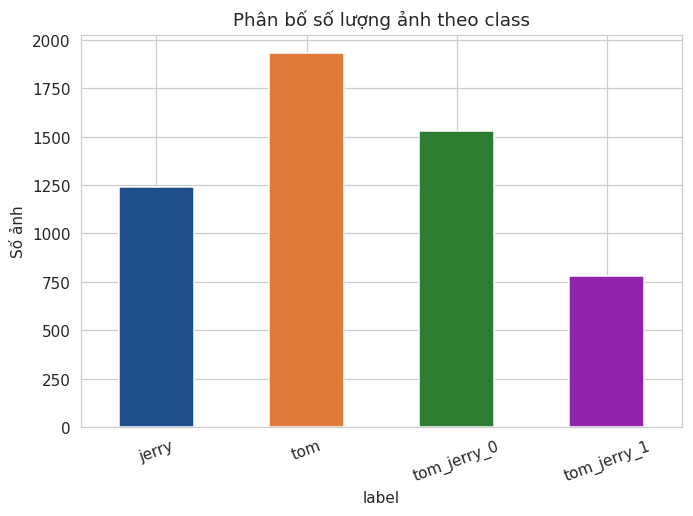

In [5]:
# Gom danh sách toàn bộ file ảnh + nhãn tương ứng
records = []
for c in CLASSES:
    for f in (CLASS_ROOT / c).glob("*"):
        if f.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({"filepath": str(f), "label": c})

df = pd.DataFrame(records)
print("Tổng số ảnh:", len(df))
print(df["label"].value_counts())

df["label"].value_counts().reindex(CLASSES).plot(kind="bar", color=["#1f4e8c", "#e07b39", "#2e7d32", "#8e24aa"])
plt.title("Phân bố số lượng ảnh theo class")
plt.ylabel("Số ảnh")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


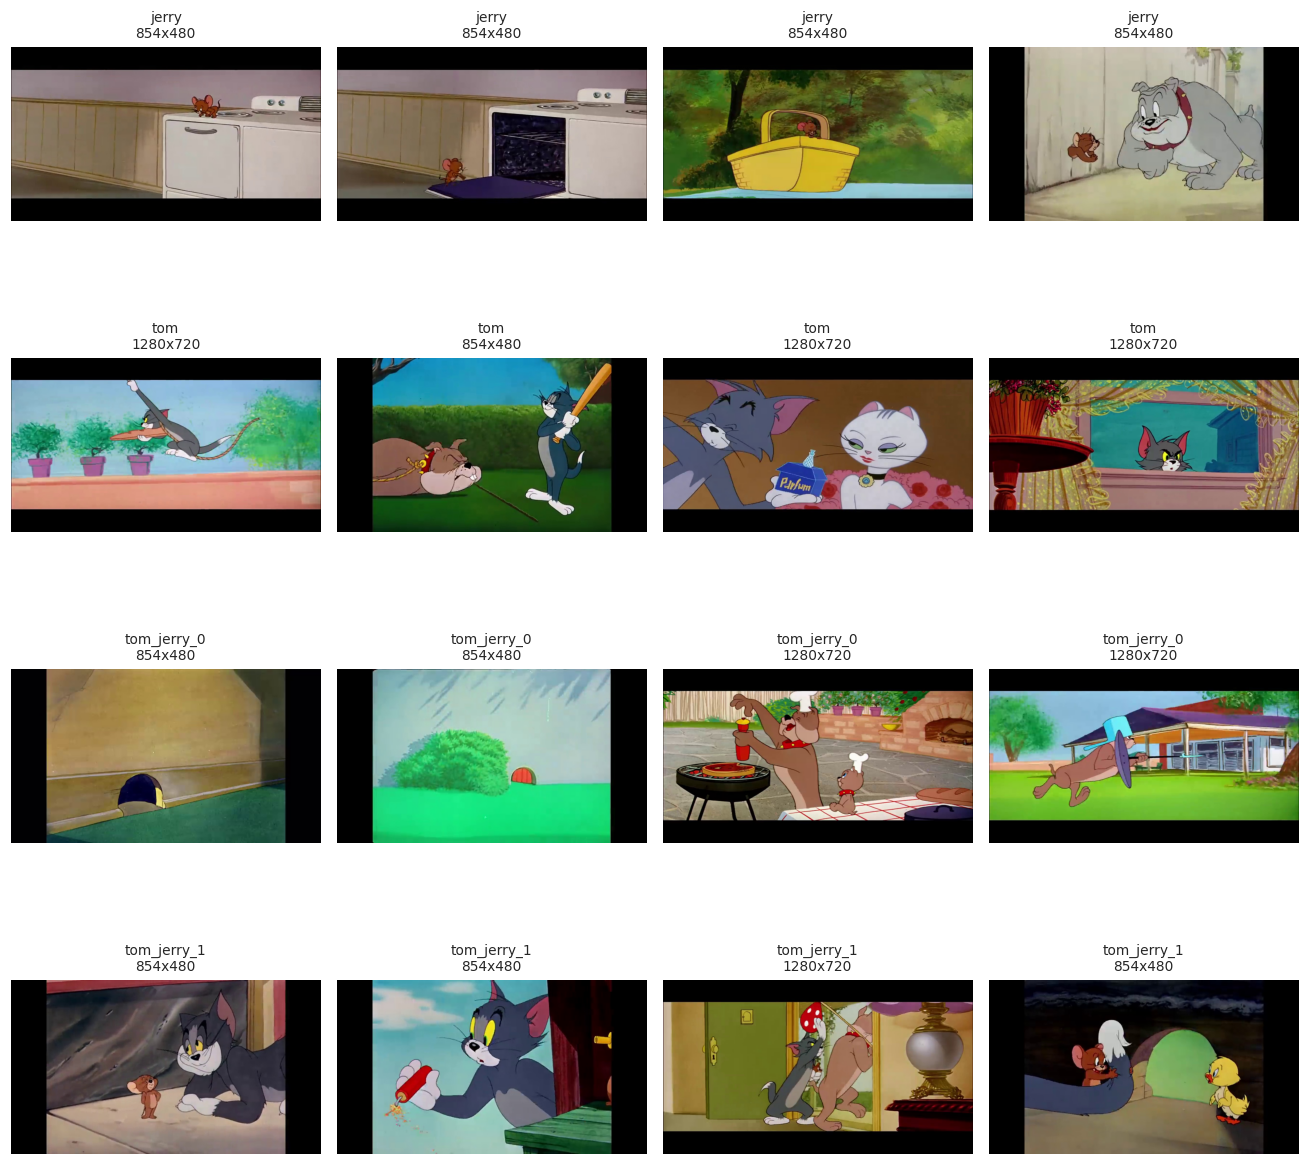

In [6]:
# Xem thử vài ảnh mẫu mỗi class, kèm shape ảnh gốc (để kiểm tra có viền đen hay không)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
rng = np.random.default_rng(SEED)

for i, c in enumerate(CLASSES):
    sample_paths = df[df["label"] == c]["filepath"].sample(4, random_state=SEED).tolist()
    for j, p in enumerate(sample_paths):
        img = cv2.imread(p)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img_rgb)
        axes[i, j].set_title(f"{c}\n{img.shape[1]}x{img.shape[0]}", fontsize=9)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()


## 3. Bước 2 (pipeline): Preprocess — Loại bỏ viền đen

Vì ảnh được trích từ video (nhiều nguồn / tỉ lệ khung hình khác nhau), một số frame có thể có
**viền đen (letterbox/pillarbox)** ở trên-dưới hoặc trái-phải do padding khi convert video sang ảnh tĩnh.

Chiến lược crop: quét từ mép ảnh vào trong, cắt bỏ các hàng/cột có độ sáng trung bình dưới ngưỡng
(gần như đen tuyền), dừng lại khi gặp hàng/cột "đủ sáng" đầu tiên. Cách này an toàn — nếu ảnh không
có viền đen, hàm sẽ không cắt gì cả (trả về ảnh gốc).

In [7]:
def remove_black_border(img_bgr, brightness_thresh=15, min_content_ratio=0.05):
    """
    Cắt bỏ viền đen (letterbox/pillarbox) quanh ảnh.

    Parameters
    ----------
    img_bgr : np.ndarray
        Ảnh gốc (BGR, như đọc từ cv2.imread).
    brightness_thresh : int
        Ngưỡng độ sáng trung bình (0-255) để coi 1 hàng/cột là "đen".
    min_content_ratio : float
        Tỉ lệ tối thiểu kích thước ảnh phải giữ lại (tránh crop quá tay nếu cả ảnh tối).

    Returns
    -------
    np.ndarray : ảnh đã crop viền đen.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    row_means = gray.mean(axis=1)  # độ sáng trung bình mỗi hàng
    col_means = gray.mean(axis=0)  # độ sáng trung bình mỗi cột

    def find_bounds(means, size):
        lo = 0
        hi = size - 1
        min_keep = int(size * min_content_ratio)
        while lo < hi and means[lo] < brightness_thresh:
            lo += 1
        while hi > lo and means[hi] < brightness_thresh:
            hi -= 1
        # Bảo toàn tối thiểu min_content_ratio kích thước, tránh crop hỏng ảnh toàn tối
        if hi - lo < min_keep:
            return 0, size - 1
        return lo, hi

    top, bottom = find_bounds(row_means, h)
    left, right = find_bounds(col_means, w)

    cropped = img_bgr[top:bottom + 1, left:right + 1]
    if cropped.size == 0:
        return img_bgr
    return cropped


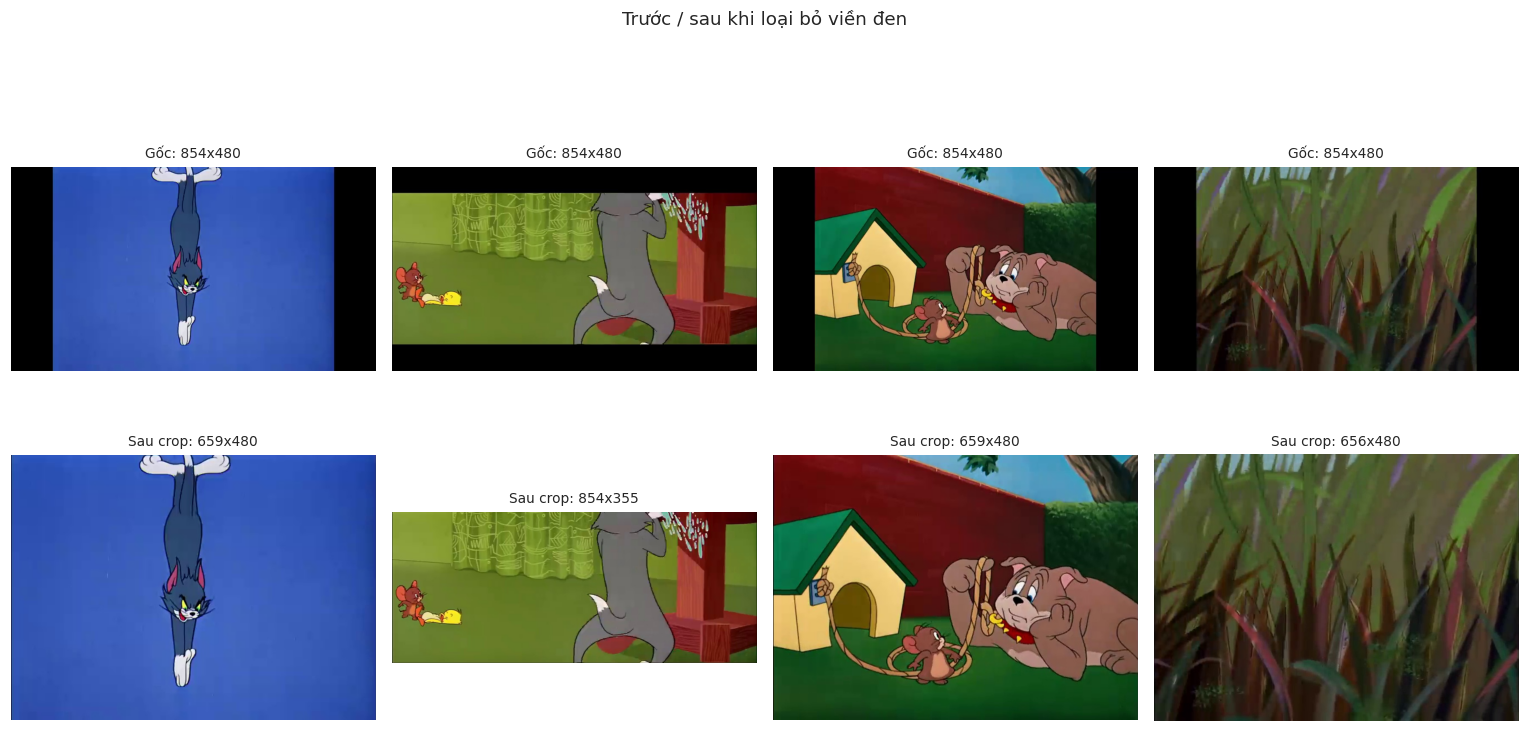

In [8]:
# Demo trực quan hàm remove_black_border trên vài ảnh mẫu
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
demo_paths = df.sample(4, random_state=SEED)["filepath"].tolist()

for j, p in enumerate(demo_paths):
    img = cv2.imread(p)
    cropped = remove_black_border(img)

    axes[0, j].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, j].set_title(f"Gốc: {img.shape[1]}x{img.shape[0]}", fontsize=9)
    axes[0, j].axis("off")

    axes[1, j].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    axes[1, j].set_title(f"Sau crop: {cropped.shape[1]}x{cropped.shape[0]}", fontsize=9)
    axes[1, j].axis("off")

plt.suptitle("Trước / sau khi loại bỏ viền đen", y=1.02)
plt.tight_layout()
plt.show()


## 4. Bước 3 (pipeline): Feature Extraction — HOG + RGB Histogram

Kết hợp 2 loại đặc trưng bổ trợ cho nhau:

- **HOG (Histogram of Oriented Gradients):** nắm bắt *hình dạng/cấu trúc* — đường viền nhân vật, tư thế, texture.
  Rất phù hợp để phân biệt "có Tom", "có Jerry" dựa trên contour đặc trưng.
- **RGB Histogram:** nắm bắt *phân bố màu sắc* toàn ảnh (Tom màu xám-xanh, Jerry màu nâu, background từng cảnh
  khác nhau) — bổ sung thông tin mà HOG (vốn hoạt động trên ảnh grayscale) bỏ lỡ.

Cả hai được resize về cùng kích thước chuẩn trước khi trích đặc trưng để đảm bảo vector đặc trưng có
chiều dài cố định cho mọi ảnh.

In [9]:
IMG_SIZE = (128, 128)     # kích thước chuẩn hoá trước khi trích đặc trưng
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HIST_BINS = 32           # số bin mỗi kênh màu


def extract_hog_features(img_bgr, size=IMG_SIZE):
    """Trích đặc trưng HOG từ ảnh grayscale đã resize."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
    features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        feature_vector=True,
    )
    return features


def extract_rgb_histogram(img_bgr, size=IMG_SIZE, bins=HIST_BINS):
    """Trích RGB histogram (mỗi kênh 1 histogram, đã normalize) từ ảnh đã resize."""
    img_resized = cv2.resize(img_bgr, size, interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    hist_features = []
    for channel in range(3):
        hist = cv2.calcHist([img_rgb], [channel], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.append(hist)

    return np.concatenate(hist_features)


def extract_combined_features(img_bgr):
    """Bước 3+4 pipeline: trích HOG + RGB histogram rồi concatenate."""
    hog_feat = extract_hog_features(img_bgr)
    hist_feat = extract_rgb_histogram(img_bgr)
    return np.concatenate([hog_feat, hist_feat])


# Kiểm tra nhanh chiều dài vector đặc trưng
_sample_img = cv2.imread(df["filepath"].iloc[0])
_sample_cropped = remove_black_border(_sample_img)
_hog_len = len(extract_hog_features(_sample_cropped))
_hist_len = len(extract_rgb_histogram(_sample_cropped))
print(f"HOG feature length      : {_hog_len}")
print(f"RGB histogram length    : {_hist_len}")
print(f"Total combined length   : {_hog_len + _hist_len}")


HOG feature length      : 8100
RGB histogram length    : 96
Total combined length   : 8196


## 5. Trích xuất đặc trưng cho toàn bộ dataset

**Lưu ý về hiệu năng:** dataset có ~5.478 ảnh. Trích HOG cho toàn bộ có thể mất vài phút trên CPU.
Nếu muốn thử nhanh trước, đặt `SUBSET_PER_CLASS` xuống một số nhỏ (vd. 300); đặt `None` để dùng toàn bộ dataset.

In [10]:
SUBSET_PER_CLASS = None   # đặt vd. 300 để test nhanh, None để dùng full dataset

if SUBSET_PER_CLASS is not None:
    df_use = (
        df.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), SUBSET_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )
else:
    df_use = df.reset_index(drop=True)

print("Số ảnh sẽ dùng:", len(df_use))
print(df_use["label"].value_counts())


Số ảnh sẽ dùng: 5478
label
tom            1930
tom_jerry_0    1528
jerry          1240
tom_jerry_1     780
Name: count, dtype: int64


In [11]:
def build_feature_matrix(dataframe, verbose_every=500):
    """Đọc ảnh -> loại viền đen -> trích HOG+RGB histogram cho toàn bộ dataframe."""
    X, y, bad_files = [], [], []
    t0 = time.time()

    for i, row in enumerate(dataframe.itertuples(index=False)):
        img = cv2.imread(row.filepath)
        if img is None:
            bad_files.append(row.filepath)
            continue

        img = remove_black_border(img)
        feat = extract_combined_features(img)
        X.append(feat)
        y.append(row.label)

        if verbose_every and (i + 1) % verbose_every == 0:
            elapsed = time.time() - t0
            print(f"  Đã xử lý {i + 1}/{len(dataframe)} ảnh ({elapsed:.1f}s)")

    print(f"Hoàn tất trong {time.time() - t0:.1f}s. Ảnh lỗi/không đọc được: {len(bad_files)}")
    return np.array(X, dtype=np.float32), np.array(y), bad_files


X_raw, y_raw, bad_files = build_feature_matrix(df_use)
print("Feature matrix shape:", X_raw.shape)
print("Labels shape:", y_raw.shape)


  Đã xử lý 500/5478 ảnh (12.4s)
  Đã xử lý 1000/5478 ảnh (24.8s)
  Đã xử lý 1500/5478 ảnh (37.5s)
  Đã xử lý 2000/5478 ảnh (51.9s)
  Đã xử lý 2500/5478 ảnh (66.1s)
  Đã xử lý 3000/5478 ảnh (79.2s)
  Đã xử lý 3500/5478 ảnh (91.7s)
  Đã xử lý 4000/5478 ảnh (104.5s)
  Đã xử lý 4500/5478 ảnh (117.2s)
  Đã xử lý 5000/5478 ảnh (130.1s)
Hoàn tất trong 142.5s. Ảnh lỗi/không đọc được: 0
Feature matrix shape: (5478, 8196)
Labels shape: (5478,)


## 6. Bước 4 (pipeline): Concatenate & Normalize Features

HOG và RGB histogram đã được `concatenate` ở bước trích đặc trưng (`extract_combined_features`).
Bước còn lại là **normalize (chuẩn hoá)** toàn bộ vector đặc trưng bằng `StandardScaler`
(zero mean, unit variance) — quan trọng với SVM vì kernel RBF dựa trên khoảng cách Euclidean,
nếu không chuẩn hoá thì các đặc trưng có scale lớn (HOG) sẽ lấn át các đặc trưng scale nhỏ.

Ta chia dữ liệu theo tỉ lệ **70% train / 15% validation / 15% test**, dùng `stratify` để giữ tỉ lệ
class đồng đều ở cả 3 tập (dataset vốn mất cân bằng giữa các class).

In [12]:
# Train / Validation / Test split (70/15/15), stratified theo label
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=SEED, stratify=y_raw
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train : {X_train.shape[0]} ảnh")
print(f"Val   : {X_val.shape[0]} ảnh")
print(f"Test  : {X_test.shape[0]} ảnh")

for name, arr in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = pd.Series(arr).value_counts().reindex(CLASSES)
    print(f"\n{name} distribution:\n{counts}")


Train : 3834 ảnh
Val   : 822 ảnh
Test  : 822 ảnh

Train distribution:
jerry           868
tom            1351
tom_jerry_0    1069
tom_jerry_1     546
Name: count, dtype: int64

Val distribution:
jerry          186
tom            289
tom_jerry_0    230
tom_jerry_1    117
Name: count, dtype: int64

Test distribution:
jerry          186
tom            290
tom_jerry_0    229
tom_jerry_1    117
Name: count, dtype: int64


In [13]:
# Normalize: fit StandardScaler CHỈ trên train set, rồi transform cả 3 tập
# (tránh data leakage — không được để thông tin từ val/test rò rỉ vào lúc fit scaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Đã chuẩn hoá xong. Mean train (~0):", X_train_scaled.mean().round(4),
      "| Std train (~1):", X_train_scaled.std().round(4))


Đã chuẩn hoá xong. Mean train (~0): 0.0 | Std train (~1): 1.0


## 7. Bước 5+6 (pipeline): Soft-margin SVM (RBF) + One-vs-One

Theo lý thuyết đã học trong slide:
- **Soft-margin SVM**: cho phép vi phạm margin có kiểm soát qua slack variables $\xi_n$ và hệ số $C$
  (tham số điều chỉnh trade-off giữa margin rộng và số lỗi phân loại).
- **Kernel RBF**: $K(x, z) = \exp(-\gamma \|x - z\|^2)$, ánh xạ dữ liệu sang không gian đặc trưng
  vô hạn chiều để tìm ranh giới phi tuyến — cần thiết vì dữ liệu ảnh gần như chắc chắn không
  linearly separable trong không gian đặc trưng HOG+histogram gốc.
- **One-vs-One**: vì đây là bài toán 4 lớp (`tom`, `jerry`, `tom_jerry_0`, `tom_jerry_1`), scikit-learn's
  `SVC` mặc định dùng chiến lược One-vs-One (huấn luyện $\binom{4}{2}=6$ bộ phân loại nhị phân,
  quyết định bằng voting) — đúng như bước 6 trong pipeline đề xuất.

Ta dùng `GridSearchCV` để tìm `C` và `gamma` tốt nhất trên tập validation (thực chất dùng CV trên train,
rồi so sánh lại bằng validation set riêng để chọn mô hình cuối).

In [14]:
from sklearn.model_selection import GridSearchCV

# Grid search nhỏ gọn để tìm C, gamma tốt (dùng cross-validation trên train set)
param_grid = {
    "C": [1, 10, 50],
    "gamma": ["scale", 0.01, 0.001],
}

base_svm = SVC(kernel="rbf", decision_function_shape="ovo", class_weight="balanced", random_state=SEED)

grid_search = GridSearchCV(
    base_svm, param_grid,
    cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
)

print("Đang chạy Grid Search (có thể mất vài phút)...")
grid_search.fit(X_train_scaled, y_train)

print("\nBest params:", grid_search.best_params_)
print("Best CV f1_macro score:", round(grid_search.best_score_, 4))


Đang chạy Grid Search (có thể mất vài phút)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best params: {'C': 10, 'gamma': 'scale'}
Best CV f1_macro score: 0.7583


In [15]:
# Đánh giá nhanh mô hình best trên tập validation, để chắc chắn không overfit vào CV fold
best_svm_candidate = grid_search.best_estimator_
val_preds = best_svm_candidate.predict(X_val_scaled)
val_f1 = f1_score(y_val, val_preds, average="macro")
print(f"F1-macro trên Validation set: {val_f1:.4f}")
print(classification_report(y_val, val_preds, target_names=CLASSES))


F1-macro trên Validation set: 0.7833
              precision    recall  f1-score   support

       jerry       0.82      0.75      0.78       186
         tom       0.79      0.84      0.82       289
 tom_jerry_0       0.70      0.78      0.74       230
 tom_jerry_1       0.92      0.70      0.80       117

    accuracy                           0.78       822
   macro avg       0.81      0.77      0.78       822
weighted avg       0.79      0.78      0.78       822



In [16]:
# Huấn luyện mô hình cuối cùng: gộp train + validation, dùng best hyperparameters, One-vs-One RBF SVM
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

final_svm = SVC(
    kernel="rbf",
    C=grid_search.best_params_["C"],
    gamma=grid_search.best_params_["gamma"],
    decision_function_shape="ovo",   # One-vs-One, đúng bước 6 pipeline
    class_weight="balanced",
    probability=False,
    random_state=SEED,
)

t0 = time.time()
final_svm.fit(X_trainval_scaled, y_trainval)
print(f"Huấn luyện xong trong {time.time() - t0:.1f}s")
print(f"Số support vectors mỗi class: {final_svm.n_support_}")
print(f"Tổng support vectors: {final_svm.n_support_.sum()} / {len(X_trainval_scaled)} samples")


Huấn luyện xong trong 206.4s
Số support vectors mỗi class: [1012 1570 1251  647]
Tổng support vectors: 4480 / 4656 samples


## 8. Đánh giá trên Test Set

Đây là **kết quả cần nộp**: Accuracy, Precision, Recall, F1-score, và Confusion Matrix — tính hoàn toàn
trên tập test (chưa hề được mô hình nhìn thấy trong quá trình huấn luyện hay tune hyperparameter).

In [17]:
y_pred = final_svm.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

prec_weighted = precision_score(y_test, y_pred, average="weighted")
rec_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("="*55)
print("KẾT QUẢ TRÊN TEST SET")
print("="*55)
print(f"Accuracy               : {acc:.4f}")
print(f"Precision (macro avg)  : {prec_macro:.4f}")
print(f"Recall    (macro avg)  : {rec_macro:.4f}")
print(f"F1-score  (macro avg)  : {f1_macro:.4f}")
print("-"*55)
print(f"Precision (weighted)   : {prec_weighted:.4f}")
print(f"Recall    (weighted)   : {rec_weighted:.4f}")
print(f"F1-score  (weighted)   : {f1_weighted:.4f}")
print("="*55)


KẾT QUẢ TRÊN TEST SET
Accuracy               : 0.7944
Precision (macro avg)  : 0.8144
Recall    (macro avg)  : 0.7792
F1-score  (macro avg)  : 0.7933
-------------------------------------------------------
Precision (weighted)   : 0.7987
Recall    (weighted)   : 0.7944
F1-score  (weighted)   : 0.7939


In [18]:
# Classification report chi tiết theo từng class
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))


              precision    recall  f1-score   support

       jerry     0.7966    0.7581    0.7769       186
         tom     0.7737    0.8724    0.8201       290
 tom_jerry_0     0.7733    0.7598    0.7665       229
 tom_jerry_1     0.9140    0.7265    0.8095       117

    accuracy                         0.7944       822
   macro avg     0.8144    0.7792    0.7933       822
weighted avg     0.7987    0.7944    0.7939       822



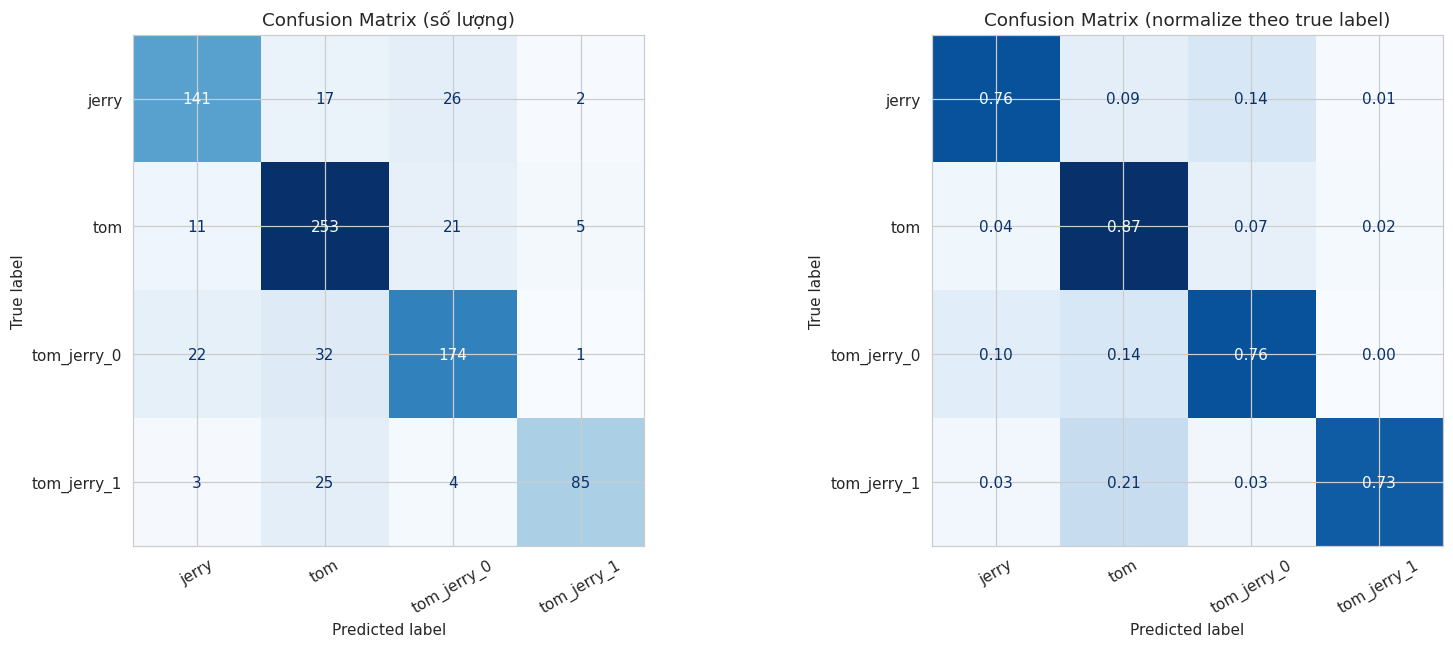

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion matrix - số lượng tuyệt đối
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=30)
axes[0].set_title("Confusion Matrix (số lượng)")

# Confusion matrix - normalize theo hàng (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASSES)
disp2.plot(ax=axes[1], cmap="Blues", colorbar=False, xticks_rotation=30, values_format=".2f")
axes[1].set_title("Confusion Matrix (normalize theo true label)")

plt.tight_layout()
plt.show()


In [20]:
# Tổng hợp lại thành 1 bảng kết quả cuối, dễ copy vào báo cáo
per_class_precision = precision_score(y_test, y_pred, average=None, labels=CLASSES)
per_class_recall = recall_score(y_test, y_pred, average=None, labels=CLASSES)
per_class_f1 = f1_score(y_test, y_pred, average=None, labels=CLASSES)
support = pd.Series(y_test).value_counts().reindex(CLASSES).values

summary_df = pd.DataFrame({
    "class": CLASSES,
    "precision": per_class_precision.round(4),
    "recall": per_class_recall.round(4),
    "f1_score": per_class_f1.round(4),
    "support": support,
})

overall_row = pd.DataFrame([{
    "class": "TỔNG (macro avg)",
    "precision": round(prec_macro, 4),
    "recall": round(rec_macro, 4),
    "f1_score": round(f1_macro, 4),
    "support": support.sum(),
}])

summary_df = pd.concat([summary_df, overall_row], ignore_index=True)
summary_df


,class,precision,recall,f1_score,support
0,jerry,0.7966,0.7581,0.7769,186
1,tom,0.7737,0.8724,0.8201,290
2,tom_jerry_0,0.7733,0.7598,0.7665,229
3,tom_jerry_1,0.9140,0.7265,0.8095,117
4,TỔNG (macro avg),0.8144,0.7792,0.7933,822


## 9. Phân tích lỗi (bonus, giúp hiểu mô hình hơn)

Xem thử một vài ảnh bị phân loại sai để hiểu điểm yếu của pipeline hiện tại (thường là các lớp
`tom_jerry_0` / `tom_jerry_1` dễ nhầm nhất, vì phụ thuộc vào việc HOG+histogram có bắt được
sự hiện diện của nhân vật hay không).

Số ảnh phân loại sai: 169 / 822 (20.6%)


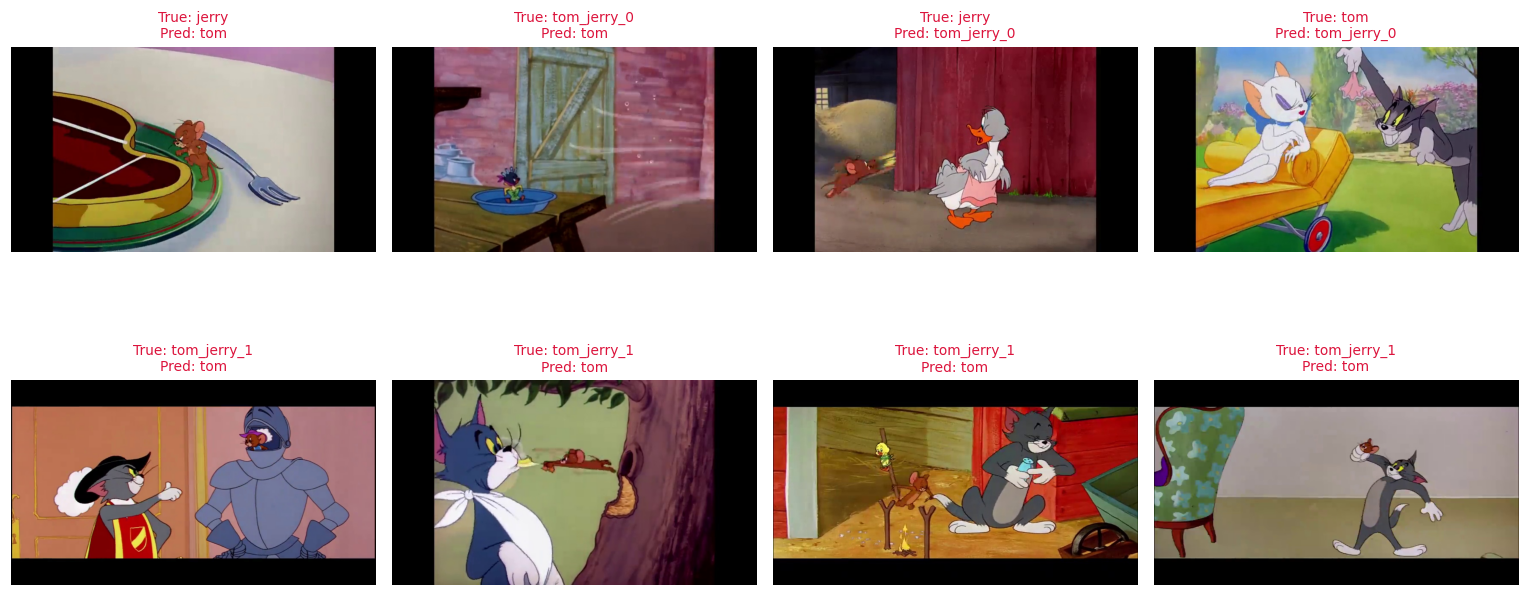

In [21]:
# Cần map lại index test set về filepath gốc để hiển thị ảnh sai
test_idx = np.arange(len(X_raw))
# Lấy lại đúng thứ tự index đã split (train_test_split giữ nguyên index nếu ta truyền index riêng)
all_idx = np.arange(len(X_raw))
idx_train, idx_temp = train_test_split(all_idx, test_size=0.30, random_state=SEED, stratify=y_raw)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED,
                                      stratify=y_raw[idx_temp])

test_filepaths = df_use["filepath"].values[idx_test]

wrong_mask = y_pred != y_test
wrong_indices = np.where(wrong_mask)[0]
print(f"Số ảnh phân loại sai: {len(wrong_indices)} / {len(y_test)} "
      f"({100*len(wrong_indices)/len(y_test):.1f}%)")

n_show = min(8, len(wrong_indices))
if n_show > 0:
    show_idx = np.random.default_rng(SEED).choice(wrong_indices, n_show, replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, i in zip(axes.flat, show_idx):
        img = cv2.imread(test_filepaths[i])
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"True: {y_test[i]}\nPred: {y_pred[i]}", fontsize=9, color="crimson")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 10. Lưu mô hình

Lưu SVM đã huấn luyện + scaler để có thể tái sử dụng cho inference sau này mà không cần train lại.

In [22]:
os.makedirs("model_artifacts", exist_ok=True)

dump(final_svm, "model_artifacts/svm_tom_jerry.joblib")
dump(scaler, "model_artifacts/scaler_tom_jerry.joblib")

# Lưu luôn config trích đặc trưng để đảm bảo consistency lúc inference
feature_config = {
    "IMG_SIZE": IMG_SIZE,
    "HOG_ORIENTATIONS": HOG_ORIENTATIONS,
    "HOG_PIXELS_PER_CELL": HOG_PIXELS_PER_CELL,
    "HOG_CELLS_PER_BLOCK": HOG_CELLS_PER_BLOCK,
    "HIST_BINS": HIST_BINS,
    "CLASSES": CLASSES,
    "best_params": grid_search.best_params_,
    "test_accuracy": float(acc),
    "test_f1_macro": float(f1_macro),
}

import json as _json
with open("model_artifacts/feature_config.json", "w") as f:
    _json.dump(feature_config, f, indent=2)

print("Đã lưu model tại model_artifacts/")
print(feature_config)


Đã lưu model tại model_artifacts/
{'IMG_SIZE': (128, 128), 'HOG_ORIENTATIONS': 9, 'HOG_PIXELS_PER_CELL': (8, 8), 'HOG_CELLS_PER_BLOCK': (2, 2), 'HIST_BINS': 32, 'CLASSES': ['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1'], 'best_params': {'C': 10, 'gamma': 'scale'}, 'test_accuracy': 0.7944038929440389, 'test_f1_macro': 0.7932500955442909}


## 11. Hàm inference (dự đoán ảnh mới)

Hàm tiện ích để dự đoán 1 ảnh bất kỳ, dùng lại đúng pipeline: loại viền đen → HOG+RGB histogram → normalize → predict.

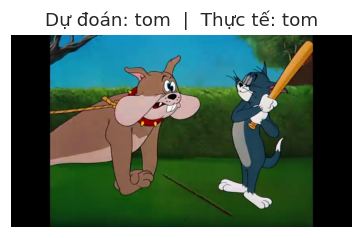

In [23]:
def predict_single_image(image_path, model=final_svm, scaler=scaler):
    """Dự đoán class cho 1 ảnh mới, dùng đúng pipeline đã huấn luyện."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Không đọc được ảnh: {image_path}")

    img = remove_black_border(img)
    feat = extract_combined_features(img).reshape(1, -1)
    feat_scaled = scaler.transform(feat)

    pred = model.predict(feat_scaled)[0]
    decision = model.decision_function(feat_scaled)[0]

    return pred, decision


# Demo trên 1 ảnh test bất kỳ
demo_path = test_filepaths[0]
pred_label, decision_scores = predict_single_image(demo_path)

img = cv2.imread(demo_path)
plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Dự đoán: {pred_label}  |  Thực tế: {y_test[0]}")
plt.axis("off")
plt.show()


---
## Tổng kết

Notebook đã hoàn thành đầy đủ pipeline theo yêu cầu bài tập:

| Bước | Nội dung | Trạng thái |
|---|---|---|
| 1 | Input: image frame Tom & Jerry | ✅ Tải từ Kaggle, 4 classes |
| 2 | Preprocess: loại bỏ viền đen | ✅ `remove_black_border()` |
| 3 | Feature extraction: HOG + RGB histogram | ✅ `extract_combined_features()` |
| 4 | Concatenate & normalize features | ✅ `np.concatenate` + `StandardScaler` |
| 5 | Model: Soft-margin SVM (RBF) | ✅ `SVC(kernel="rbf", C=..., gamma=...)` |
| 6 | Output: One-vs-One voting | ✅ `decision_function_shape="ovo"` |
| — | Accuracy, Precision, Recall, F1, Confusion Matrix | ✅ Section 8 |

**Gợi ý cải thiện nếu muốn nâng điểm:**
- Thử thêm đặc trưng LBP (Local Binary Pattern) hoặc color moments để tăng khả năng phân biệt.
- Áp dụng PCA để giảm chiều vector đặc trưng (HOG khá dài), có thể giúp SVM train nhanh hơn mà không mất nhiều accuracy.
- Data augmentation (flip, rotate nhẹ) nếu class bị mất cân bằng nhiều.
- So sánh thêm với linear SVM / polynomial kernel để thấy rõ RBF thực sự cần thiết hay không (liên hệ Kernel SVM trong slide III).
